# Imports

In [1]:
import os
import sys

In [2]:
current_dir =  os.getcwd()
# replace this following line in the path your frank2d files are.
parent_dir = os.path.abspath(os.path.join(current_dir, os.pardir))
sys.path.append(parent_dir)

In [3]:
parent_dir

'/localhome/home/zgdz996/frank2d'

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import time

In [5]:
# frank2d
from frank2d import Frank2D
from frank2d.geometry import Geometry
from frank2d.plot import Plot
from frank2d.posterior_optimization import *
from frank2d.constants import rad_to_arcsec, deg_to_rad
from frank2d.posterior_optimization import MAPEstimator

In [6]:
dir = "./../../data/"
data_file = dir + "uvtable_nonsym_disc_blob_noisy.npz"
inc = 0
pa = 0
dra = 0
ddec = 0
rout = 1*2

# Load data
file = np.load(data_file)
u, v, Vis, Weights = file['u'], file['v'], file['vis'], file['weights']
uvtable = {'u': u, 'v': v, 'vis': Vis, 'weights': Weights }

geom = Geometry(inc, pa, dra, ddec)

## F2D

In [7]:
Ns = [300, 500, 1000, 1500]

In [8]:
params_N80 = {'m': -4.572459366888535, 'c': 1.0086866109221515e+24, 'l': 68720.91547274287}

### separated

In [9]:
frank2d = Frank2D(300, rout)
frank2d.fit(uvtable, kernel_params = params_N80, rtol =1e-10)

===>  Setting gridded data...
===>  Setting GP Kernel wend...
        + Kernel parameters:  {'m': -4.572459366888535, 'c': 1.0086866109221515e+24, 'l': 68720.91547274287}
===>  Creating sparse linear system...
        +  Kernel = 0.03  min |  1.94 seconds
        +  Building system = 0.03  min |  2.00 seconds
===>  Solving linear system...
      .... iteration  0 :   actual tol  1.22e+08  versus  1.22e-02
      .... iteration  10 :   actual tol  3.71e+07  versus  1.22e-02
      .... iteration  20 :   actual tol  1.53e+06  versus  1.22e-02
      .... iteration  30 :   actual tol  1.14e+06  versus  1.22e-02
      .... iteration  40 :   actual tol  2.48e+05  versus  1.22e-02
      .... iteration  50 :   actual tol  1.47e+05  versus  1.22e-02
      .... iteration  60 :   actual tol  4.30e+04  versus  1.22e-02
      .... iteration  70 :   actual tol  4.88e+04  versus  1.22e-02
      .... iteration  80 :   actual tol  9.23e+03  versus  1.22e-02
      .... iteration  90 :   actual tol  3.34e+

In [12]:
times_sep = []

In [13]:
for i in Ns:
    frank2d = Frank2D(i, rout)
    start = time.time()
    frank2d.fit(uvtable, kernel_params = params_N80, rtol =1e-10)
    end = time.time()
    times_sep.append(end - start)
    print(f"N={i}, time={end - start} seconds")

===>  Setting gridded data...
===>  Setting GP Kernel wend...
        + Kernel parameters:  {'m': -4.572459366888535, 'c': 1.0086866109221515e+24, 'l': 68720.91547274287}
===>  Creating sparse linear system...
        +  Kernel = 0.03  min |  1.93 seconds
        +  Building system = 0.03  min |  1.98 seconds
===>  Solving linear system...
      .... iteration  0 :   actual tol  1.22e+08  versus  1.22e-02
      .... iteration  10 :   actual tol  3.71e+07  versus  1.22e-02
      .... iteration  20 :   actual tol  1.53e+06  versus  1.22e-02
      .... iteration  30 :   actual tol  1.14e+06  versus  1.22e-02
      .... iteration  40 :   actual tol  2.48e+05  versus  1.22e-02
      .... iteration  50 :   actual tol  1.47e+05  versus  1.22e-02
      .... iteration  60 :   actual tol  4.30e+04  versus  1.22e-02
      .... iteration  70 :   actual tol  4.88e+04  versus  1.22e-02
      .... iteration  80 :   actual tol  9.23e+03  versus  1.22e-02
      .... iteration  90 :   actual tol  3.34e+

In [17]:
times_sep = [18.7110493183136, 23.610445976257324, 38.4596529006958, 60.016735553741455]

Text(0.5, 1.0, 'Frank2D')

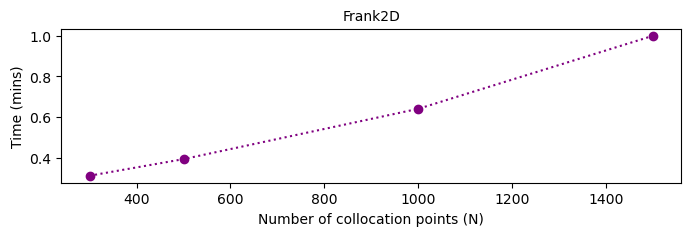

In [16]:
plt.figure(figsize=(8,2))
plt.plot(Ns, np.array(times_sep)/60, marker='o', ls=':', color = 'purple')
#plt.xscale('log')
#plt.yscale('log')
plt.xlabel('Number of collocation points (N)', fontsize=10)
plt.ylabel('Time (mins)', fontsize=10)
plt.title(f'Frank2D', fontsize=10)

### Non separated

In [9]:
frank2d = Frank2D(300, rout)
frank2d.fit(uvtable, kernel_params = params_N80, rtol =1e-10)

===>  Setting gridded data...
----------------------Number of weighted data points: 41873
===>  Setting GP Kernel wend...
        + Kernel parameters:  {'m': -4.572459366888535, 'c': 1.0086866109221515e+24, 'l': 68720.91547274287}
===>  Creating sparse linear system...
        +  Kernel = 0.10  min |  6.05 seconds
        +  Building system = 0.10  min |  6.23 seconds
===>  Solving linear system...
      .... iteration  0 :   actual tol  1.22e+08  versus  1.22e-02
      .... iteration  10 :   actual tol  3.77e+07  versus  1.22e-02
      .... iteration  20 :   actual tol  2.21e+06  versus  1.22e-02
      .... iteration  30 :   actual tol  1.22e+06  versus  1.22e-02
      .... iteration  40 :   actual tol  1.30e+05  versus  1.22e-02
      .... iteration  50 :   actual tol  4.00e+04  versus  1.22e-02
      .... iteration  60 :   actual tol  3.22e+04  versus  1.22e-02
      .... iteration  70 :   actual tol  2.38e+04  versus  1.22e-02
      .... iteration  80 :   actual tol  1.43e+04  vers

In [18]:
times_non_sep = [28.94524884223938, 51.011874198913574, 163.87662935256958, 337.95832228660583]

In [10]:
for i in Ns:
    frank2d = Frank2D(i, rout)
    start = time.time()
    frank2d.fit(uvtable, kernel_params = params_N80, rtol =1e-10)
    end = time.time()
    times_non_sep.append(end - start)
    print(f"N={i}, time={end - start} seconds")

===>  Setting gridded data...
===>  Setting GP Kernel wend...
        + Kernel parameters:  {'m': -4.572459366888535, 'c': 1.0086866109221515e+24, 'l': 68720.91547274287}
===>  Creating sparse linear system...
        +  Kernel = 0.09  min |  5.27 seconds
        +  Building system = 0.09  min |  5.43 seconds
===>  Solving linear system...
      .... iteration  0 :   actual tol  1.22e+08  versus  1.22e-02
      .... iteration  10 :   actual tol  3.77e+07  versus  1.22e-02
      .... iteration  20 :   actual tol  2.21e+06  versus  1.22e-02
      .... iteration  30 :   actual tol  1.22e+06  versus  1.22e-02
      .... iteration  40 :   actual tol  1.30e+05  versus  1.22e-02
      .... iteration  50 :   actual tol  4.00e+04  versus  1.22e-02
      .... iteration  60 :   actual tol  3.22e+04  versus  1.22e-02
      .... iteration  70 :   actual tol  2.38e+04  versus  1.22e-02
      .... iteration  80 :   actual tol  1.43e+04  versus  1.22e-02
      .... iteration  90 :   actual tol  1.05e+

Text(0.5, 1.0, 'Frank2D')

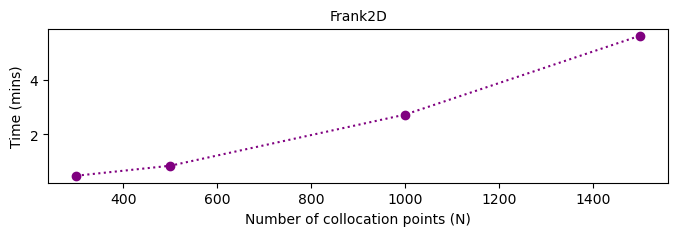

In [11]:
plt.figure(figsize=(8,2))
plt.plot(Ns, np.array(times_non_sep)/60, marker='o', ls=':', color = 'purple')
#plt.xscale('log')
#plt.yscale('log')
plt.xlabel('Number of collocation points (N)', fontsize=10)
plt.ylabel('Time (mins)', fontsize=10)
plt.title(f'Frank2D', fontsize=10)

### Joined graphs

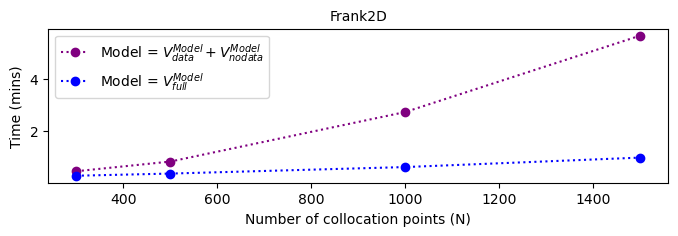

In [23]:
plt.figure(figsize=(8,2))
plt.plot(Ns, np.array(times_non_sep)/60, marker='o', ls=':', color = 'purple', label = r"Model = $V_{data}^{Model} + V_{no data}^{Model}$")
plt.plot(Ns, np.array(times_sep)/60, marker='o', ls=':', color = 'blue', label = r"Model = $V_{full}^{Model}$")
plt.xlabel('Number of collocation points (N)', fontsize=10)
plt.ylabel('Time (mins)', fontsize=10)
plt.title(f'Frank2D', fontsize=10)
plt.legend()